In [33]:
import os

# download the dataset using Kaggle CLI


# Ensure Kaggle API is installed and up-to-date
!pip install kaggle --upgrade -q

# Create .kaggle directory and move kaggle.json
!mkdir -p ~/.kaggle
# Assuming kaggle.json is uploaded to the current working directory
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

# Unzip the downloaded file
# The dataset name is typically the slug with .zip appended
!unzip cell-images-for-detecting-malaria.zip

# Remove the zip file after extraction to save space
!rm cell-images-for-detecting-malaria.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:19<00:00, 36.9MB/s]

Archive:  cell-images-for-detecting-malaria.zip
replace cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [34]:
# import essential librareies
import numpy as np
np.random.seed(42)
import cv2
import os
from PIL import Image
import keras
from keras.layers import Conv2D , MaxPooling2D , Flatten , Dense , Input , BatchNormalization , Dropout
os.environ['KERAS_BACKEND']='tensorflow'

In [35]:
# design the network
input_shape= (64 , 64 , 3)
inp = Input(shape = input_shape)
conv1 = Conv2D(32 , kernel_size=(3,3), activation='relu', padding='same')(inp)
max1= MaxPooling2D(pool_size=(2,2))(conv1)
norm1 = BatchNormalization()(max1)
drop1= Dropout(0.25)(norm1)

conv2 = Conv2D(32 , kernel_size=(3,3), activation='relu', padding='same')(drop1)
max2= MaxPooling2D(pool_size=(2,2))(conv2)
norm2 = BatchNormalization()(max2)
drop2= Dropout(0.25)(norm2)

flat= Flatten()(drop2)

hidden1= Dense(512 , activation='relu')(flat)
norm3 = BatchNormalization()(hidden1)
drop3= Dropout(0.25)(norm3)

hidden2= Dense(512 , activation='relu')(drop3)
norm4 = BatchNormalization()(hidden2)
drop4= Dropout(0.25)(norm4)

output= Dense(2 , activation='sigmoid')(drop4)

model = keras.Model(inputs= inp , outputs= output)

model.compile(optimizer='adam' , loss='binary_crossentropy' , metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,472,994 (17.06 MB)

 Trainable params: 4,470,818 (17.05 MB)

 Non-trainable params: 2,176 (8.50 KB)

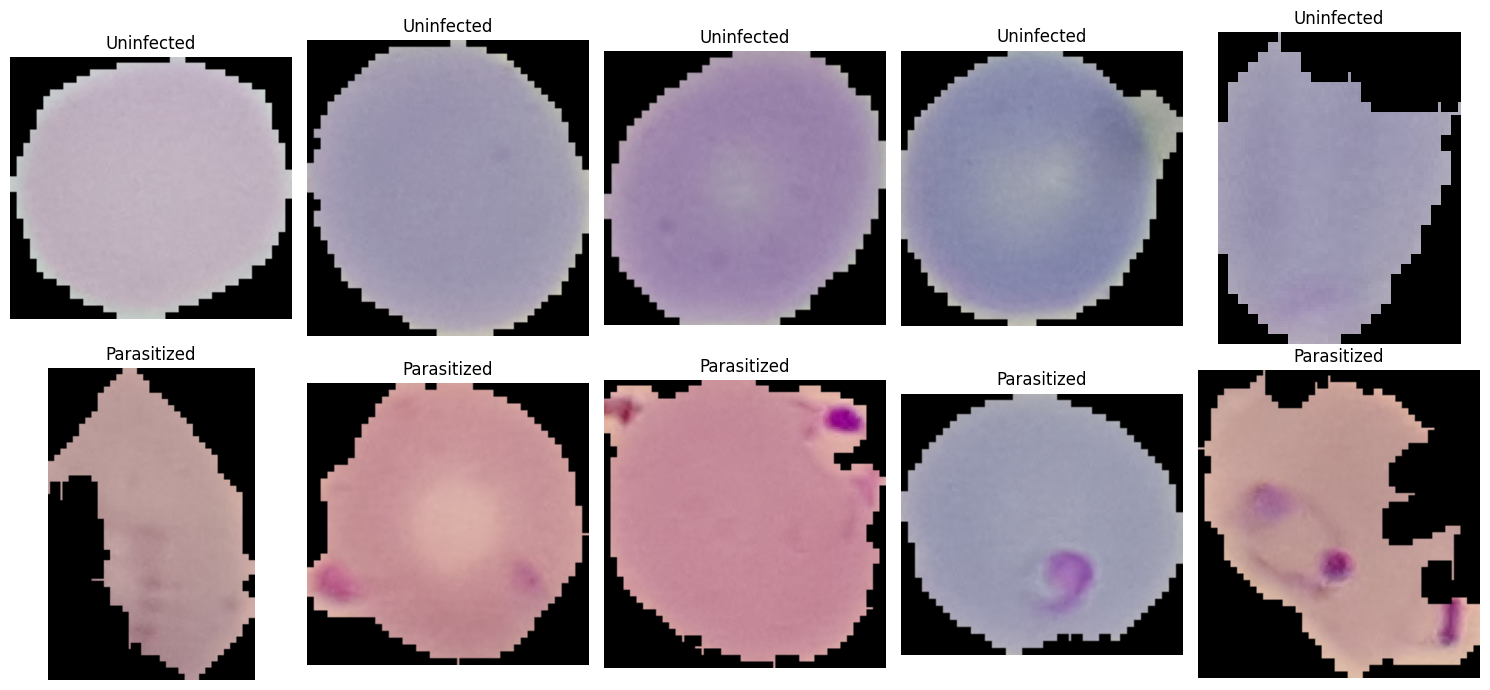

In [36]:
import matplotlib.pyplot as plt
import random

# Define the paths to the image directories
uninfected_path = 'cell_images/cell_images/Uninfected/'
parasitized_path = 'cell_images/cell_images/Parasitized/'

# Get a list of image filenames from each category
uninfected_images = os.listdir(uninfected_path)
parasitized_images = os.listdir(parasitized_path)

# Select 5 random images from each category
num_images_to_show = 5
random_uninfected = random.sample(uninfected_images, num_images_to_show)
random_parasitized = random.sample(parasitized_images, num_images_to_show)

# Create a figure to display the images
plt.figure(figsize=(15, 7))

# Display uninfected images
for i, img_name in enumerate(random_uninfected):
    img_path = os.path.join(uninfected_path, img_name)
    img = Image.open(img_path)
    plt.subplot(2, num_images_to_show, i + 1)  # 2 rows, 5 columns
    plt.imshow(img)
    plt.title('Uninfected')
    plt.axis('off')

# Display parasitized images
for i, img_name in enumerate(random_parasitized):
    img_path = os.path.join(parasitized_path, img_name)
    img = Image.open(img_path)
    plt.subplot(2, num_images_to_show, num_images_to_show + i + 1) # Second row
    plt.imshow(img)
    plt.title('Parasitized')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
len(uninfected_images)

13780

In [52]:
dataset = []
label=[]

for i , image_name in enumerate(uninfected_images):
    if(image_name.split('.')[1] == 'png'):
        image = cv2.imread(uninfected_path + image_name)
        image = Image.fromarray(image , 'RGB')
        image = image.resize((64 , 64))
        dataset.append(np.array(image))
        label.append(0)

/tmp/ipykernel_3545/2794442714.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image , 'RGB')


In [53]:
for i , image_name in enumerate(parasitized_images):
    if(image_name.split('.')[1] == 'png'):
        image = cv2.imread(parasitized_path + image_name)
        image = Image.fromarray(image , 'RGB')
        image = image.resize((64 , 64))
        dataset.append(np.array(image))
        label.append(1)


/tmp/ipykernel_3545/1484981949.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image , 'RGB')


In [54]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

# Convert dataset and label to numpy arrays
dataset_np = np.array(dataset)
label_np = np.array(label)

x_train , x_test , y_train , y_test = train_test_split(dataset_np , to_categorical(label_np) , test_size=0.2 , random_state=42)
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((22046, 64, 64, 3), (5512, 64, 64, 3), (22046, 2), (5512, 2))

In [56]:
# fit the model
history = model.fit(x_train , y_train, batch_size=64 , verbose=1 , validation_split=0.1 , shuffle=False, epochs=3)


Epoch 1/3
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9967 - loss: 0.0085 - val_accuracy: 0.9569 - val_loss: 0.3102
Epoch 2/3
311/311 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9977 - loss: 0.0071 - val_accuracy: 0.9592 - val_loss: 0.3228
Epoch 3/3
311/311 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9985 - loss: 0.0051 - val_accuracy: 0.9546 - val_loss: 0.3502


In [57]:
loss , accuracy = model.evaluate(x_test , y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9545 - loss: 0.3405
Test Accuracy: 95.45%


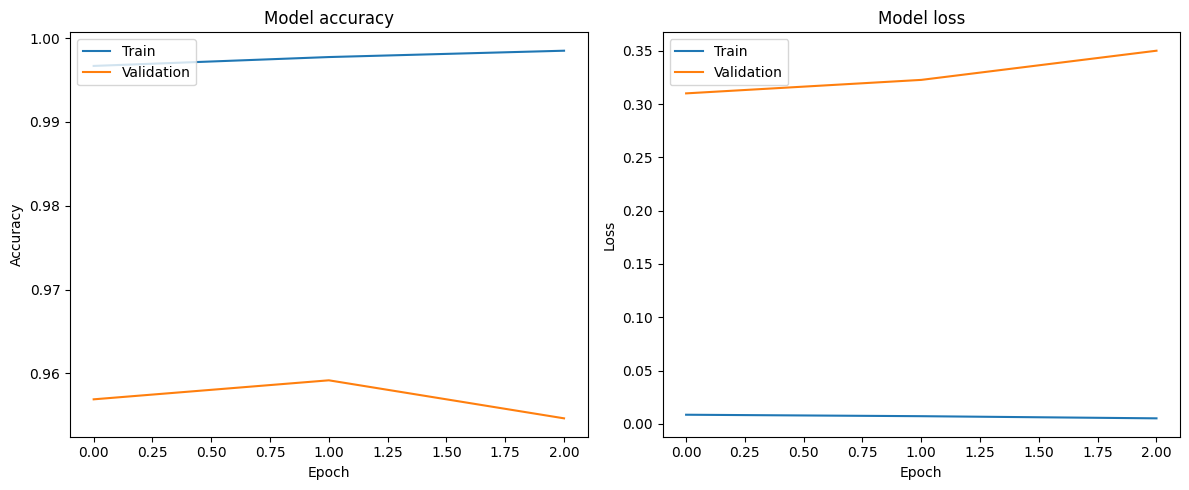

In [58]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()